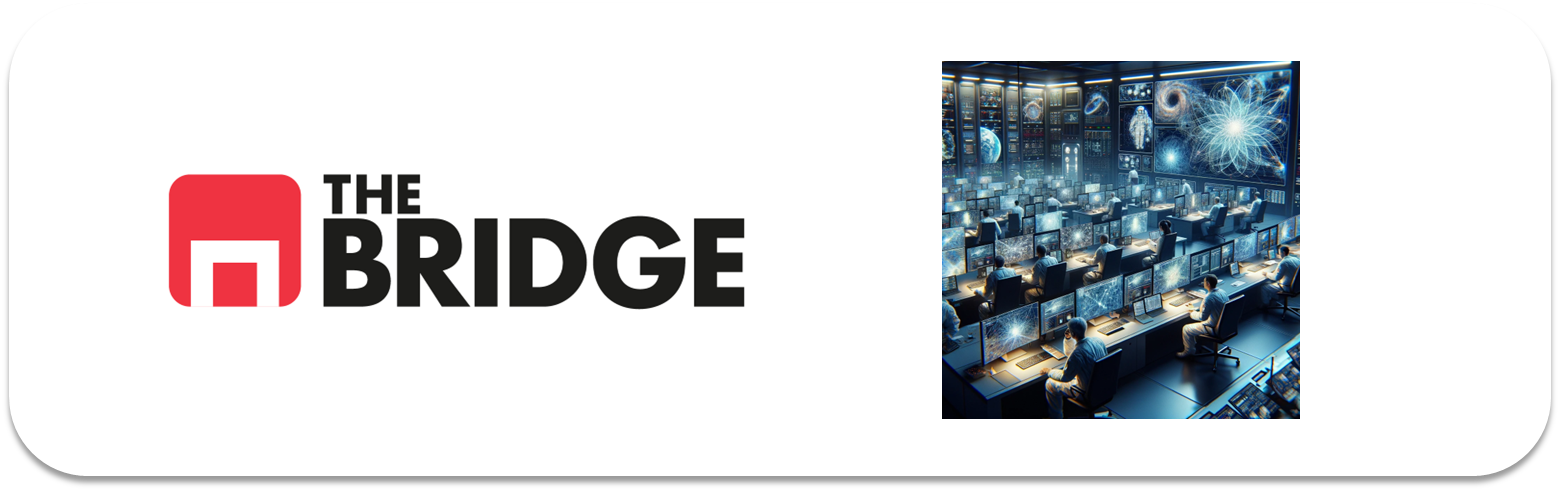

## PRACTICA OBLIGATORIA: **Redes Convolucionales**

* La práctica obligatoria de esta unidad consiste en un ejercicio de construcción de una red convolucional con Keras para la clasificación de imagenes de simpáticos perretes y gatetes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imread
import os
import cv2

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

import tensorflow
from tensorflow import keras

from keras.models import Sequential
from keras.layers import Input, Conv2D, MaxPool2D, Dropout, Flatten, Dense
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

### Problema de Negocio y dataset

Una conocida empresa de información inmobiliaria utiliza un CAPTCHA visual de perros y gatos para detectar webscrappings intensivos y ataques de denegación de servicio. Últimamente, ha detectado que su sistema está empezando a flojear, es decir que hay muchos sistemas de detección automática de imágenes que son capaces de detectar que es un perro y un gato y salterse el CAPTCHA antirobots. Por eso nos ha pedido que entrenemos un modelo potente de clasificación que emule a estos sistemas con el objetivo de emplear como fotografías para el CAPTCHA aquellas que no sepa detectar este sistema emulador de chicos malos.  

Pues manos a la obra, tenemos que seleccionar en un conjunto de 1000 imágenes aquellas que peor se le daría clasificar a un potencial sistema anti-CAPTCHA.  

Para ello vamos a emplear un conjunto de train de 4000 imágenes de perretes y gatetes que se encuentran distribuidas en "data" en cuatro directorios "github_train_0",  "github_train_1", "githun_train_2" y "github_train_3". Los datos de las imagenes que tenemos que clasificar y luego seleccionar como las más "difíciles" están en "data" en el directorio "github_test".


### Se pide

1. Crear los datasets X,y de train y test, leyendo las imágenes de los directorios correspondientes (tendrás que leer todas las imágenes de los cuatro directorios para train) y a la vez que se leen adpatar su resolución para que todas tengan un tamaño de 32x32. En este caso puedes adaptar las funciones de los ejercicios de la unidad. NOTA: Ten en cuenta que la clase a la que pertenece en la foto está en el nombre del archivo.

2. Crea un modelo DL basado en redes convolucionales con al menos dos juegos Convolucional-Pooling. Sigue todo el proceso de ML (visualización del dataset, MiniEDA, Construcción del modelo)

3. Entrenar el modelo con un callback de Earlystopping con paciencia la que tengas :-). Muestra su historial de entrenamiento.

4. Evalua el modelo, haz un reporte de clasificacion y muestra la matriz de confianza.

5. Es el momento de seleccionar las imagenes: Selecciona el 10% de imágenes mal clasificadas de una y otra clase que tengan el mayor nivel de confianza de que pertenencían a la clase errónea. Es decir las imágenes de perros clasificadas como gatos y con la probabilidad de ser perror más alta.


### Extra (para hacer en clase)

Repite los pasos 3 a 5 utilizando el generador de imágenes sintéticas o Image Augmentation de Keras. 



## Carga de datos

In [2]:
# ============================================================
# Rutas
# ============================================================
ROOT_PATH = "./data/"
TRAIN_DIRS = ["github_train_0", "github_train_1", "github_train_2", "github_train_3"]
TEST_DIR = "github_test"

In [3]:
# ============================================================
# Función para extraer la clase del nombre del fichero
# ============================================================
def extraer_clase(nombre_fichero):
    """
    Coge el nombre del fichero, p.ej: 'cat.123.jpg -> 
    se queda con lo que hay antes del primer punto.
    """
    return nombre_fichero.split(".")[0].lower()

In [4]:
# ============================================================
# Función de carga: recorre uno o varios directorios, lee cada imagen,
# la redimensiona y extrae la clase del nombre del fichero
# ============================================================
def read_data_from_dirs(directorios, reshape_dim=(32, 32)):
    X = []
    y = []

    for directorio in directorios:
        for file in os.listdir(directorio):
            ruta_file = os.path.join(directorio, file)
            if os.path.isfile(ruta_file):
                image = imread(ruta_file)
                image = cv2.resize(image, reshape_dim)
                X.append(image)
                y.append(extraer_clase(file))

    return np.array(X), np.array(y)


In [5]:
# ============================================================
# Carga de TRAIN (los 4 directorios juntos)
# ============================================================
train_dirs_full = [os.path.join(ROOT_PATH, d) for d in TRAIN_DIRS]
X_train, y_train = read_data_from_dirs(train_dirs_full, reshape_dim=(32, 32))

# ============================================================
# Carga de TEST
# ============================================================
X_test, y_test = read_data_from_dirs([os.path.join(ROOT_PATH, TEST_DIR)], reshape_dim=(32, 32))

In [6]:
# ============================================================
# Comprobaciones
# ============================================================
print("X_train:", X_train.shape, " y_train:", y_train.shape)
print("X_test:", X_test.shape, " y_test:", y_test.shape)

print("\nClases en train:", np.unique(y_train, return_counts=True))
print("Clases en test:", np.unique(y_test, return_counts=True))

print("\nFormas únicas encontradas en X_train (comprobación de homogeneidad):")
print(set(img.shape for img in X_train))

X_train: (4000, 32, 32, 3)  y_train: (4000,)
X_test: (1000, 32, 32, 3)  y_test: (1000,)

Clases en train: (array(['cat', 'dog'], dtype='<U3'), array([2000, 2000]))
Clases en test: (array(['cat', 'dog'], dtype='<U3'), array([500, 500]))

Formas únicas encontradas en X_train (comprobación de homogeneidad):
{(32, 32, 3)}


## Visualización datos

In [7]:
# ============================================================
# Resumen general
# ============================================================
print("=== Resumen general ===")
print(f"Imágenes en train: {X_train.shape[0]}")
print(f"Imágenes en test:  {X_test.shape[0]}")
print(f"Dimensiones por imagen: {X_train.shape[1:]}")
print(f"Clases: {sorted(np.unique(y_train))}")

=== Resumen general ===
Imágenes en train: 4000
Imágenes en test:  1000
Dimensiones por imagen: (32, 32, 3)
Clases: [np.str_('cat'), np.str_('dog')]



=== Distribución de clases (train) ===
  cat: 2000 (50.0%)
  dog: 2000 (50.0%)

=== Distribución de clases (test) ===
  cat: 500 (50.0%)
  dog: 500 (50.0%)


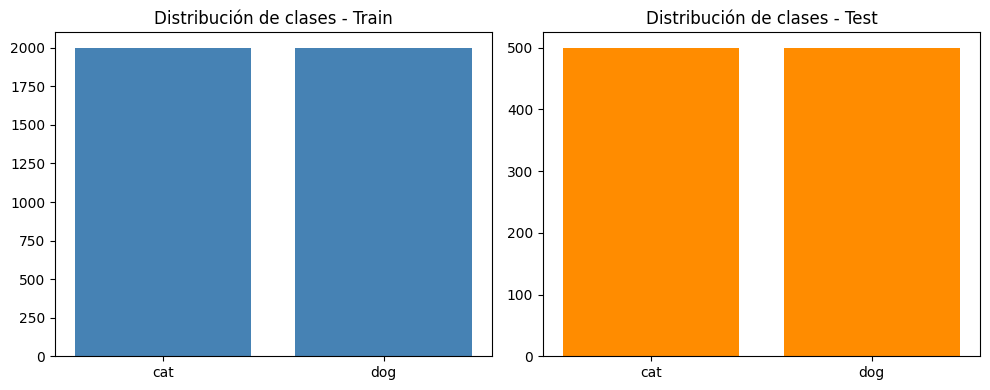

In [8]:
# ============================================================
# Distribución de clases
# ============================================================
clases_train, counts_train = np.unique(y_train, return_counts=True)
clases_test, counts_test = np.unique(y_test, return_counts=True)

print("\n=== Distribución de clases (train) ===")
for c, n in zip(clases_train, counts_train):
    print(f"  {c}: {n} ({n / len(y_train) * 100:.1f}%)")

print("\n=== Distribución de clases (test) ===")
for c, n in zip(clases_test, counts_test):
    print(f"  {c}: {n} ({n / len(y_test) * 100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(clases_train, counts_train, color="steelblue")
axes[0].set_title("Distribución de clases - Train")
axes[1].bar(clases_test, counts_test, color="darkorange")
axes[1].set_title("Distribución de clases - Test")
plt.tight_layout()
plt.show()


=== Muestras de train ===


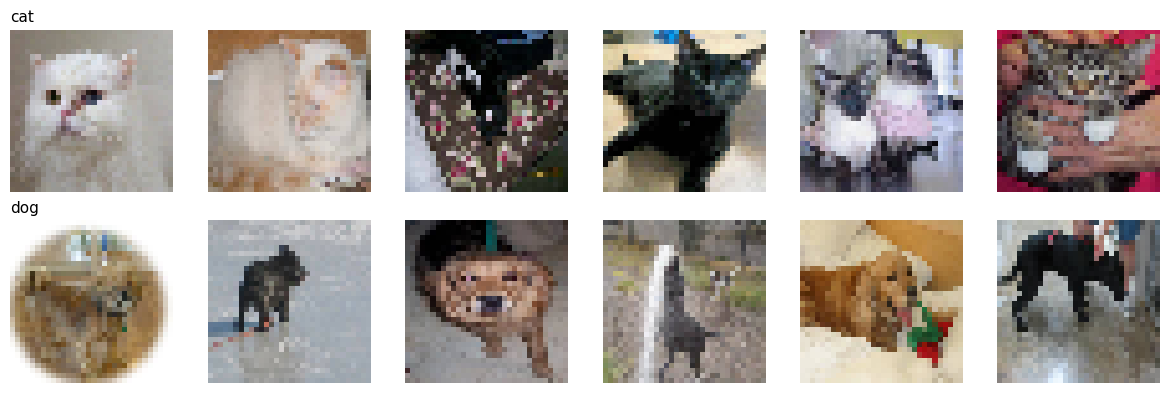

In [9]:
# ============================================================
# Visualización de muestras aleatorias por clase
# ============================================================
def plot_random_samples(X, y, n_por_clase=6, seed=42):
    rng = np.random.default_rng(seed)
    clases = np.unique(y)
    fig, axes = plt.subplots(len(clases), n_por_clase,
                              figsize=(n_por_clase * 2, len(clases) * 2))
    for i, clase in enumerate(clases):
        idx_clase = np.where(y == clase)[0]
        idx_muestra = rng.choice(idx_clase, size=n_por_clase, replace=False)
        for j, idx in enumerate(idx_muestra):
            ax = axes[i, j]
            ax.imshow(X[idx])
            ax.axis("off")
            if j == 0:
                ax.set_title(clase, loc="left", fontsize=11)
    plt.tight_layout()
    plt.show()

print("\n=== Muestras de train ===")
plot_random_samples(X_train, y_train, n_por_clase=6)

## MiniEDA

In [10]:
# --- Estadísticos globales de los píxeles ---
print("=== Estadísticos de píxeles (train, sin normalizar) ===")
print(f"Min: {X_train.min()}  Max: {X_train.max()}")
print(f"Media: {X_train.mean():.2f}  Desv. estándar: {X_train.std():.2f}")

=== Estadísticos de píxeles (train, sin normalizar) ===
Min: 0  Max: 255
Media: 115.67  Desv. estándar: 66.03


In [11]:
# --- Estadísticos por canal (R, G, B) ---
print("\n=== Estadísticos por canal (train) ===")
for i, canal in enumerate(["R", "G", "B"]):
    print(f"  Canal {canal} -> media: {X_train[:, :, :, i].mean():.2f}, "
          f"std: {X_train[:, :, :, i].std():.2f}")


=== Estadísticos por canal (train) ===
  Canal R -> media: 124.67, std: 66.34
  Canal G -> media: 115.96, std: 64.85
  Canal B -> media: 106.39, std: 65.62


In [12]:
# --- Comparativa de estadísticos por clase (¿se ven cat y dog distintos en color/intensidad?) ---
print("\n=== Estadísticos por clase ===")
for clase in np.unique(y_train):
    idx = np.where(y_train == clase)[0]
    print(f"  {clase}: media={X_train[idx].mean():.2f}, std={X_train[idx].std():.2f}")


=== Estadísticos por clase ===
  cat: media=114.62, std=67.21
  dog: media=116.73, std=64.81


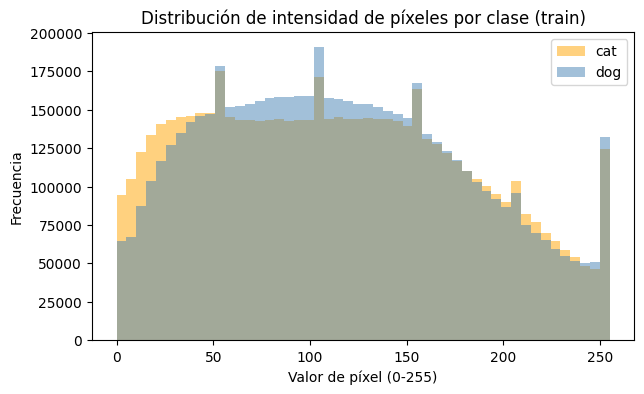

In [13]:
# --- Histograma de intensidad de píxeles, comparando ambas clases ---
plt.figure(figsize=(7, 4))
for clase, color in zip(["cat", "dog"], ["orange", "steelblue"]):
    idx = np.where(y_train == clase)[0]
    plt.hist(X_train[idx].ravel(), bins=50, alpha=0.5, label=clase, color=color)
plt.title("Distribución de intensidad de píxeles por clase (train)")
plt.xlabel("Valor de píxel (0-255)")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

In [14]:
# --- Comprobación de duplicados exactos (puede pasar en datasets de scraping) ---
X_train_flat = X_train.reshape(X_train.shape[0], -1)
n_duplicados = X_train.shape[0] - len(np.unique(X_train_flat, axis=0))
print(f"\nImágenes duplicadas exactas en train: {n_duplicados}")


Imágenes duplicadas exactas en train: 1


In [15]:
# --- Comprobación de valores nulos/corruptos ---
print(f"Valores NaN en X_train: {np.isnan(X_train.astype('float32')).sum()}")

Valores NaN en X_train: 0



=== Tras la normalización ===
dtype: float32
Min: 0.0  Max: 1.0
Media: 0.4536


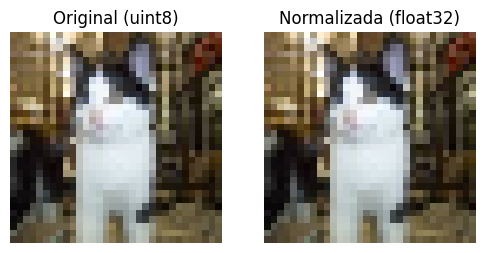

In [16]:
# Normalización de features
# ============================================================
X_train_norm = X_train.astype("float32") / 255.0
X_test_norm = X_test.astype("float32") / 255.0

print("\n=== Tras la normalización ===")
print(f"dtype: {X_train_norm.dtype}")
print(f"Min: {X_train_norm.min()}  Max: {X_train_norm.max()}")
print(f"Media: {X_train_norm.mean():.4f}")

# --- Comprobación visual de que la normalización no altera la imagen ---
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(X_train[0]); axes[0].set_title("Original (uint8)"); axes[0].axis("off")
axes[1].imshow(X_train_norm[0]); axes[1].set_title("Normalizada (float32)"); axes[1].axis("off")
plt.show()

### Conclusión del Mini-EDA

- **Dataset limpio**: 4000 imágenes en train (2000 cat / 2000 dog) y 1000 en test (500/500), perfectamente balanceado, sin valores nulos y con solo 1 imagen duplicada (irrelevante).
- **Formas homogéneas**: todas las imágenes en `(32, 32, 3)` tras el resize, sin canales inconsistentes.
- **Sin sesgo evidente entre clases**: las estadísticas de intensidad de píxeles (media y desviación estándar) son muy similares entre `cat` y `dog`, y sus histogramas se solapan casi por completo. Esto descarta que el modelo pueda "hacer trampa" aprendiendo a distinguir por brillo/color en vez de por forma o textura real del animal.
- **Alta variabilidad visual dentro de cada clase**: encuadres, ángulos, iluminación y elementos distractores (manos, telas, fondos) muy dispares — típico de un dataset de scraping real, lo que anticipa que habrá errores de clasificación en imágenes con oclusiones o encuadres atípicos.
- **Normalización aplicada** correctamente (`uint8` [0,255] → `float32` [0,1]), sin alterar el contenido visual de las imágenes.

**Conclusión general**: el dataset está en buen estado para entrenar un modelo CNN sin necesidad de limpieza adicional; la dificultad del problema vendrá de la variabilidad natural de las fotos, no de problemas de calidad de los datos.

## Construcción del modelo

In [17]:
# ============================================================
# Codificación de etiquetas (binaria: cat/dog)
# ============================================================
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)   # cat -> 0, dog -> 1 
y_test_enc = le.transform(y_test)

print("Clases:", le.classes_)
print("Ejemplo:", y_train[0], "->", y_train_enc[0])

input_shape = X_train_norm.shape[1:]  # (32, 32, 3)
print("Input shape:", input_shape)


Clases: ['cat' 'dog']
Ejemplo: cat -> 0
Input shape: (32, 32, 3)


In [18]:
# ============================================================
# Split train/val estratificado
# ============================================================
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_norm, y_train_enc,
    test_size=0.2,
    stratify=y_train_enc,
    random_state=42
)
print("X_tr:", X_tr.shape, " X_val:", X_val.shape)


X_tr: (3200, 32, 32, 3)  X_val: (800, 32, 32, 3)


In [19]:
# ============================================================
# Comprobación de la estratificación
# ============================================================
print("=== Distribución de clases en X_tr (train tras el split) ===")
clases_tr, counts_tr = np.unique(y_tr, return_counts=True)
for c, n in zip(clases_tr, counts_tr):
    print(f"  Clase {c} ({le.classes_[c]}): {n} ({n / len(y_tr) * 100:.2f}%)")

print("\n=== Distribución de clases en X_val (validación) ===")
clases_val, counts_val = np.unique(y_val, return_counts=True)
for c, n in zip(clases_val, counts_val):
    print(f"  Clase {c} ({le.classes_[c]}): {n} ({n / len(y_val) * 100:.2f}%)")

print("\n=== Distribución original (antes del split) ===")
clases_orig, counts_orig = np.unique(y_train_enc, return_counts=True)
for c, n in zip(clases_orig, counts_orig):
    print(f"  Clase {c} ({le.classes_[c]}): {n} ({n / len(y_train_enc) * 100:.2f}%)")

=== Distribución de clases en X_tr (train tras el split) ===
  Clase 0 (cat): 1600 (50.00%)
  Clase 1 (dog): 1600 (50.00%)

=== Distribución de clases en X_val (validación) ===
  Clase 0 (cat): 400 (50.00%)
  Clase 1 (dog): 400 (50.00%)

=== Distribución original (antes del split) ===
  Clase 0 (cat): 2000 (50.00%)
  Clase 1 (dog): 2000 (50.00%)


In [20]:
# ============================================================
# Arquitectura de la CNN (2 bloques Conv-Pooling)
# ============================================================
model = Sequential()

# --- Capa de entrada ---
model.add(Input(shape=input_shape))     # (32, 32, 3)

# --- Bloque convolucional 1 ---
model.add(Conv2D(filters=32, kernel_size=(3, 3), padding='Same', activation='relu'))
model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))
model.add(Dropout(0.25))    
# 32X32 -> 16X16

# --- Bloque convolucional 2 ---
model.add(Conv2D(filters=64, kernel_size=(3,3), padding='Same', activation='relu'))
model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))
model.add(Dropout(0.25))
# 16X16 -> 8X8

# --- Fully connected ---
model.add(Flatten())    # 8*8*64 = 4096 features
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))   # clasificación binaria

In [21]:
# ============================================================
# Compilación
# ============================================================
optimizer = Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999)

model.compile(optimizer=optimizer,
              loss="binary_crossentropy",
              metrics=["accuracy"])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,068,481 (4.08 MB)

 Trainable params: 1,068,481 (4.08 MB)

 Non-trainable params: 0 (0.00 B)

## Entrenamiento

In [22]:
# ============================================================
# Callbacks
# ============================================================
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_model_2bloques.keras",
    monitor="val_accuracy",
    save_best_only=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-6
)

In [24]:
# ============================================================
# Entrenamiento
# ============================================================
batch_size = 128
epochs = 100

history = model.fit(
    X_tr, y_tr,
    batch_size=batch_size,
    epochs= epochs,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping, checkpoint, reduce_lr]
)

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.4909 - loss: 0.7554 - val_accuracy: 0.5000 - val_loss: 0.6931 - learning_rate: 0.0010
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.5238 - loss: 0.6927 - val_accuracy: 0.5425 - val_loss: 0.6930 - learning_rate: 0.0010
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.5469 - loss: 0.6913 - val_accuracy: 0.5275 - val_loss: 0.6916 - learning_rate: 0.0010
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.5659 - loss: 0.6853 - val_accuracy: 0.5000 - val_loss: 0.6958 - learning_rate: 0.0010
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.5759 - loss: 0.6745 - val_accuracy: 0.5875 - val_loss: 0.6720 - learning_rate: 0.0010
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.5991 - loss: 0.6626 - val_accuracy: 0.5312 - val_loss: 0.6844 - learning_rate: 0.0010
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.6356 - loss: 0.6367 - 

In [25]:
# --- Convertir el history a DataFrame ---
history_df = pd.DataFrame(history.history)
print(history_df)

    accuracy      loss  val_accuracy  val_loss  learning_rate
0   0.490938  0.755434       0.50000  0.693099         0.0010
1   0.523750  0.692699       0.54250  0.692968         0.0010
2   0.546875  0.691269       0.52750  0.691630         0.0010
3   0.565938  0.685289       0.50000  0.695750         0.0010
4   0.575938  0.674524       0.58750  0.672034         0.0010
5   0.599063  0.662596       0.53125  0.684412         0.0010
6   0.635625  0.636709       0.61250  0.652909         0.0010
7   0.671562  0.620419       0.66250  0.610561         0.0010
8   0.688125  0.593363       0.67250  0.610152         0.0010
9   0.695625  0.587036       0.68625  0.593533         0.0010
10  0.704063  0.571398       0.70875  0.580801         0.0010
11  0.713750  0.555486       0.70375  0.573479         0.0010
12  0.720312  0.552265       0.69875  0.584907         0.0010
13  0.735937  0.535668       0.70875  0.560699         0.0010
14  0.730937  0.527182       0.69875  0.573007         0.0010
15  0.75

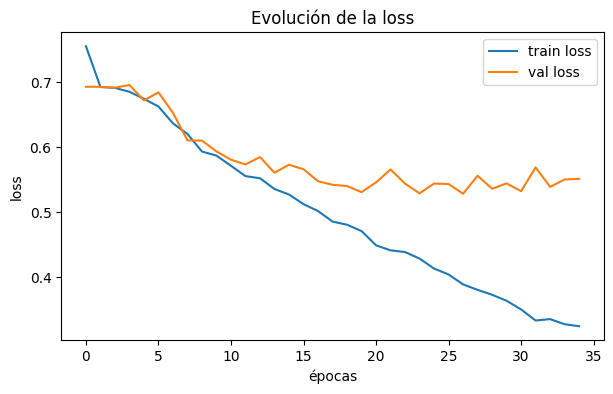

In [26]:
# --- Curvas de loss ---
plt.figure(figsize=(7, 4))
plt.plot(history_df["loss"], label="train loss")
plt.plot(history_df["val_loss"], label="val loss")
plt.title("Evolución de la loss")
plt.xlabel("épocas")
plt.ylabel("loss")
plt.legend()
plt.show()

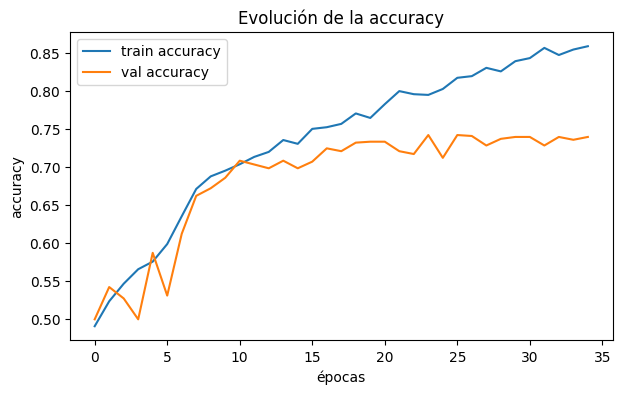

In [27]:
# --- Curvas de accuracy ---
plt.figure(figsize=(7, 4))
plt.plot(history_df["accuracy"], label="train accuracy")
plt.plot(history_df["val_accuracy"], label="val accuracy")
plt.title("Evolución de la accuracy")
plt.xlabel("épocas")
plt.ylabel("accuracy")
plt.legend()
plt.show()

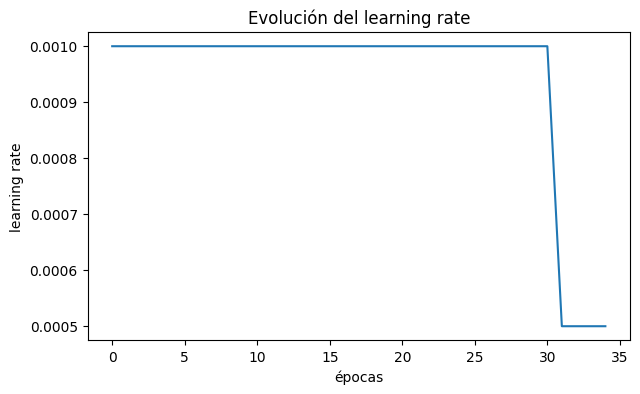

In [28]:
# --- Evolución del learning rate ---
if "learning_rate" in history_df.columns:
    plt.figure(figsize=(7, 4))
    plt.plot(history_df["learning_rate"])
    plt.title("Evolución del learning rate")
    plt.xlabel("épocas")
    plt.ylabel("learning rate")
    plt.show()

In [29]:
# --- Resumen numérico ---
print(f"\nÉpocas entrenadas: {len(history_df)}")
print(f"Mejor val_accuracy: {history_df['val_accuracy'].max():.4f} "
      f"(época {history_df['val_accuracy'].idxmax() + 1})")
print(f"Mejor val_loss: {history_df['val_loss'].min():.4f} "
      f"(época {history_df['val_loss'].idxmin() + 1})")
print(f"Accuracy final en train: {history_df['accuracy'].iloc[-1]:.4f}")
print(f"Accuracy final en validación: {history_df['val_accuracy'].iloc[-1]:.4f}")


Épocas entrenadas: 35
Mejor val_accuracy: 0.7425 (época 24)
Mejor val_loss: 0.5283 (época 27)
Accuracy final en train: 0.8594
Accuracy final en validación: 0.7400


### Conclusión del entrenamiento (modelo 2 bloques)

- **Aprendizaje inicial sano**: train y val mejoran juntas hasta ~época 10, con loss y accuracy evolucionando en paralelo.
- **Overfitting a partir de la época ~20-24**: `train_accuracy` sigue subiendo hasta 85.9%, mientras `val_accuracy` se estanca en una banda de 71-74%. `val_loss` deja de bajar y oscila con ruido entre 0.53-0.58, mientras `train_loss` sigue cayendo hasta 0.32.
- **`ReduceLROnPlateau`** actuó una vez (época 31) sin producir mejora visible en validación — el estancamiento no es un problema de learning rate, sino de capacidad/generalización del modelo.
- **Mejores resultados**: `val_accuracy` = 74.25% (época 24), `val_loss` = 0.5283 (época 27).
- **Brecha final train/val**: ~12 puntos (85.9% vs 74.0%), overfitting moderado pero claro.

**Conclusión general**: el modelo de 2 bloques alcanza un techo de generalización en torno al 73-74% de accuracy en validación. Dado el ruido visual del dataset (oclusiones, encuadres variados), es un buen candidato para probar si una arquitectura de 3 bloques Conv-Pooling logra superar ese techo.

## Evaluación en test

In [30]:
test_loss, test_accuracy = model.evaluate(X_test_norm, y_test_enc)
print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7620 - loss: 0.5192
Test loss: 0.5192487239837646
Test accuracy: 0.7620000243186951


In [31]:
# ============================================================
# Predicciones (salida sigmoide -> umbral 0.5 para clase binaria)
# ============================================================

# model.predict devuelve, para cada imagen de test, la probabilidad (0 a 1)
# de pertenecer a la clase codificada como "1" por el LabelEncoder (una sola
# neurona de salida con sigmoide -> forma (1000, 1)).
# .ravel() aplana esa matriz columna a un vector simple (1000,), más cómodo
# para comparar directamente con y_test_enc.
y_pred_probs = model.predict(X_test_norm).ravel()

# Convertimos las probabilidades continuas en una predicción de clase concreta:
# si la probabilidad es >= 0.5, predice la clase "1"; si no, la clase "0".
# (Con softmax multiclase se usaría np.argmax; aquí, con una sola neurona
# de salida, el umbral 0.5 hace ese mismo papel de "elegir la clase".)
y_pred = (y_pred_probs >= 0.5).astype(int)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


In [33]:
# ============================================================
# Classification report
# ============================================================
print("\n=== Classification report ===")
print(classification_report(y_test_enc, y_pred, target_names=le.classes_))


=== Classification report ===
              precision    recall  f1-score   support

         cat       0.76      0.76      0.76       500
         dog       0.76      0.76      0.76       500

    accuracy                           0.76      1000
   macro avg       0.76      0.76      0.76      1000
weighted avg       0.76      0.76      0.76      1000



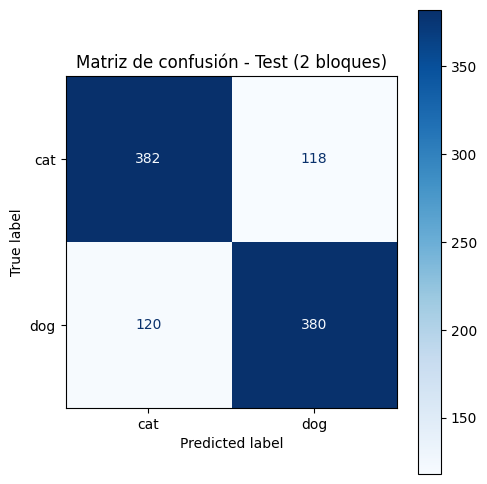

In [34]:
# ============================================================
# Matriz de confusión
# ============================================================
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_enc, y_pred,
    display_labels=le.classes_,
    ax=ax,
    cmap="Blues"
)
plt.title("Matriz de confusión - Test (2 bloques)")
plt.tight_layout()
plt.show()

### Conclusión de la matriz de confusión (Test - modelo 2 bloques)

- **Accuracy en test: 76%**, coherente con el 74% visto en validación — el modelo generaliza de forma consistente.
- **Errores simétricos entre clases**: 118 `cat` confundidos con `dog` y 120 `dog` confundidos con `cat` — precision, recall y f1 idénticos (0.76) en ambas clases, sin sesgo hacia ninguna de las dos.
- **Resultado modesto para un binario**: dado que el dataset está balanceado, el modelo acierta 3 de cada 4 imágenes.

**Conclusión general**: los errores no responden a un desequilibrio de clases, sino al ruido visual propio del dataset (oclusiones, encuadres variados) y/o a que la arquitectura de 2 bloques se queda corta para extraer features robustas frente a ese ruido — candidato claro para probar una arquitectura más profunda (3 bloques).

## Selección de imágenes

In [35]:
# ============================================================
# Identificar imágenes MAL clasificadas, separadas por dirección del error
# ============================================================
# Caso 1: reales "cat" (0) clasificadas como "dog" (1)
mask_cat_como_dog = (y_test_enc == 0) & (y_pred == 1)
idx_cat_como_dog = np.where(mask_cat_como_dog)[0]

# Caso 2: reales "dog" (1) clasificadas como "cat" (0)
mask_dog_como_cat = (y_test_enc == 1) & (y_pred == 0)
idx_dog_como_cat = np.where(mask_dog_como_cat)[0]

print(f"Cat clasificados como dog: {len(idx_cat_como_dog)}")
print(f"Dog clasificados como cat: {len(idx_dog_como_cat)}")

Cat clasificados como dog: 118
Dog clasificados como cat: 120


In [36]:
# ============================================================
# "Confianza de que pertenecían a la clase errónea":
# - Si es cat (0) predicho como dog (1): la confianza en "dog" es y_pred_probs (cerca de 1 = muy seguro de dog)
# - Si es dog (1) predicho como cat (0): la confianza en "cat" es (1 - y_pred_probs) (cerca de 1 = muy seguro de cat)
# ============================================================
confianza_cat_como_dog = y_pred_probs[idx_cat_como_dog]          # prob. de "dog", cuanto más alta, más "seguro" el error
confianza_dog_como_cat = 1 - y_pred_probs[idx_dog_como_cat]      # prob. de "cat", cuanto más alta, más "seguro" el error

# ============================================================
# Seleccionar el 10% de cada grupo con MAYOR confianza en la clase errónea
# ============================================================
n_top_cat = max(1, int(np.ceil(len(idx_cat_como_dog) * 0.10)))
n_top_dog = max(1, int(np.ceil(len(idx_dog_como_cat) * 0.10)))

top_cat_como_dog = idx_cat_como_dog[np.argsort(-confianza_cat_como_dog)][:n_top_cat]
top_dog_como_cat = idx_dog_como_cat[np.argsort(-confianza_dog_como_cat)][:n_top_dog]

print(f"\nSeleccionadas {n_top_cat} imágenes 'cat' mal clasificadas con más confianza")
print(f"Seleccionadas {n_top_dog} imágenes 'dog' mal clasificadas con más confianza")


Seleccionadas 12 imágenes 'cat' mal clasificadas con más confianza
Seleccionadas 12 imágenes 'dog' mal clasificadas con más confianza


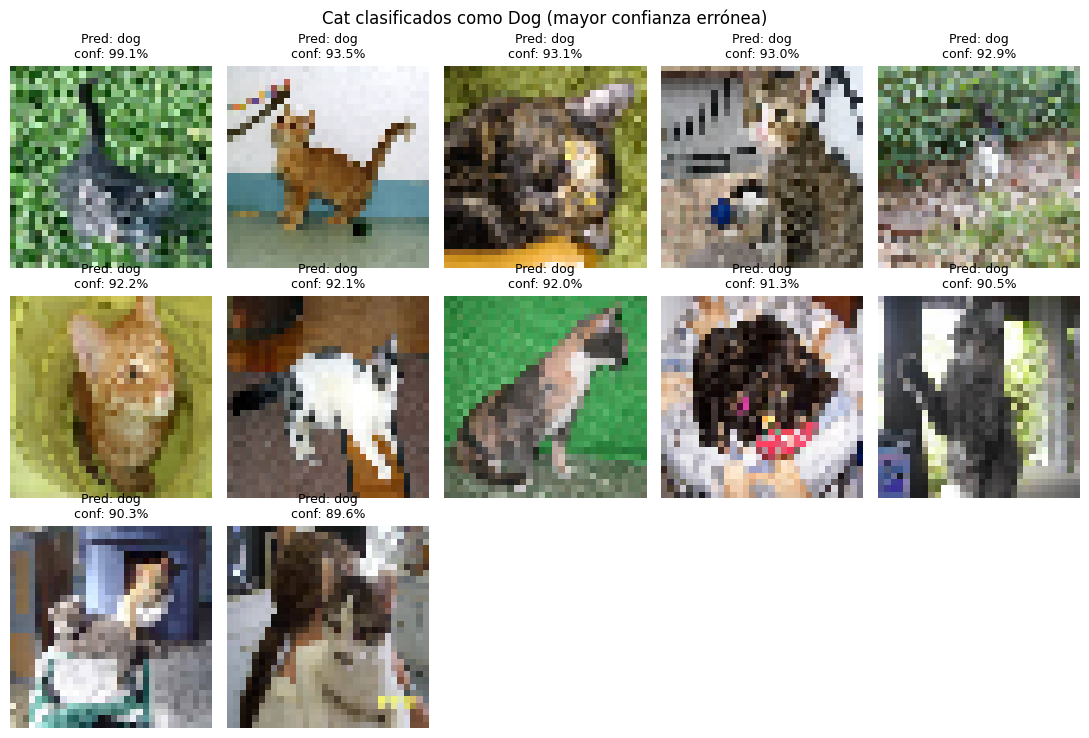

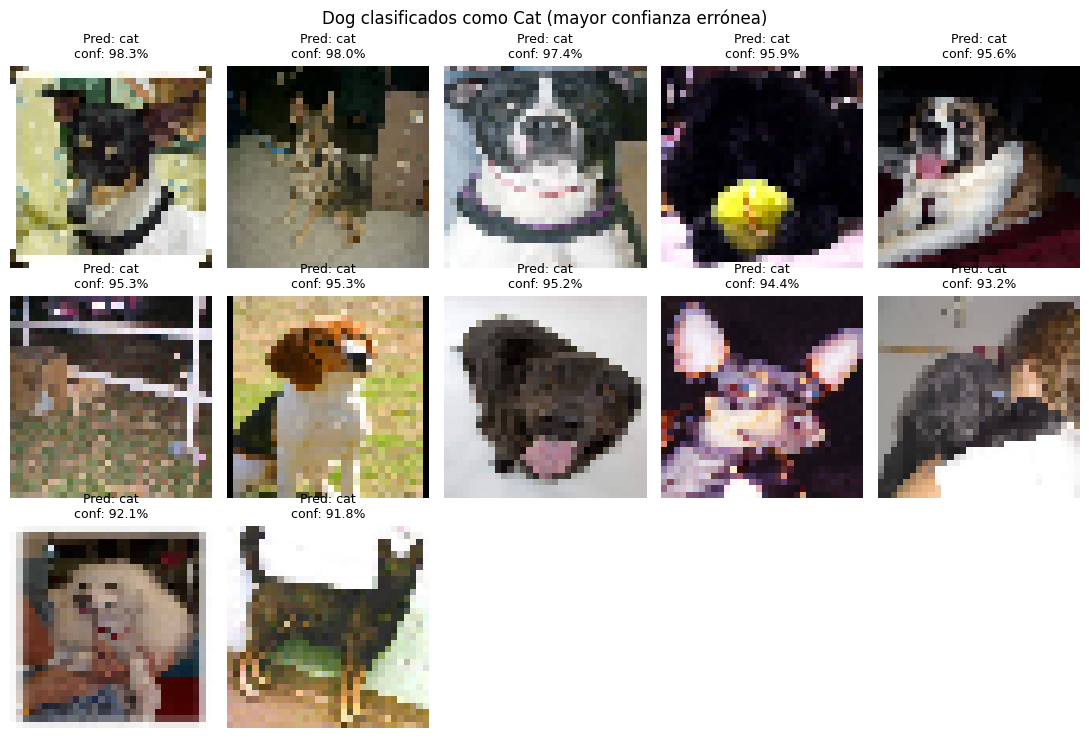

In [37]:
# ============================================================
# Visualización de las seleccionadas
# ============================================================
def plot_seleccionadas(indices, confianzas, titulo, clase_predicha):
    n = len(indices)
    n_cols = min(5, n)
    n_rows = int(np.ceil(n / n_cols))
    plt.figure(figsize=(n_cols * 2.2, n_rows * 2.5))
    for i, idx in enumerate(indices):
        plt.subplot(n_rows, n_cols, i + 1)
        plt.imshow(X_test_norm[idx])
        plt.axis("off")
        plt.title(f"Pred: {clase_predicha}\nconf: {confianzas[i]:.1%}", fontsize=9)
    plt.suptitle(titulo)
    plt.tight_layout()
    plt.show()

# Ordenamos las confianzas en el mismo orden que los índices seleccionados
conf_top_cat = confianza_cat_como_dog[np.argsort(-confianza_cat_como_dog)][:n_top_cat]
conf_top_dog = confianza_dog_como_cat[np.argsort(-confianza_dog_como_cat)][:n_top_dog]

plot_seleccionadas(top_cat_como_dog, conf_top_cat,
                    "Cat clasificados como Dog (mayor confianza errónea)", "dog")
plot_seleccionadas(top_dog_como_cat, conf_top_dog,
                    "Dog clasificados como Cat (mayor confianza errónea)", "cat")

In [38]:
# ============================================================
# Guardar las imágenes seleccionadas en disco (para el CAPTCHA)
# ============================================================

OUTPUT_DIR = "./data/captcha_candidatas_2bloques/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def guardar_imagenes(indices, prefijo):
    for i, idx in enumerate(indices):
        # Recuperamos la imagen original (sin normalizar) para guardarla con su rango real 0-255
        img_guardar = (X_test_norm[idx] * 255).astype("uint8")
        ruta = os.path.join(OUTPUT_DIR, f"{prefijo}_{i}_idx{idx}.jpg")
        plt.imsave(ruta, img_guardar)

guardar_imagenes(top_cat_como_dog, "cat_como_dog")
guardar_imagenes(top_dog_como_cat, "dog_como_cat")

print(f"\nImágenes guardadas en: {OUTPUT_DIR}")


Imágenes guardadas en: ./data/captcha_candidatas_2bloques/


## Prueba de modelo con 3 capas

In [39]:
# ============================================================
# Arquitectura de la CNN con 3 bloques Conv-Pooling
# ============================================================
model_3b = Sequential()

model_3b.add(Input(shape=input_shape))  # (32, 32, 3)

# --- Bloque convolucional 1 ---
model_3b.add(Conv2D(filters=32, kernel_size=(3, 3), padding='Same', activation='relu'))
model_3b.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))
model_3b.add(Dropout(0.25))
# 32x32 -> 16x16

# --- Bloque convolucional 2 ---
model_3b.add(Conv2D(filters=64, kernel_size=(3, 3), padding='Same', activation='relu'))
model_3b.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))
model_3b.add(Dropout(0.25))
# 16x16 -> 8x8

# --- Bloque convolucional 3 (nuevo) ---
model_3b.add(Conv2D(filters=128, kernel_size=(3, 3), padding='Same', activation='relu'))
model_3b.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))
model_3b.add(Dropout(0.25))
# 8x8 -> 4x4

# --- Fully connected ---
model_3b.add(Flatten())  # 4*4*128 = 2048 features
model_3b.add(Dense(256, activation="relu"))
model_3b.add(Dropout(0.5))
model_3b.add(Dense(1, activation="sigmoid"))

optimizer = Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999)
model_3b.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["accuracy"])
model_3b.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 618,049 (2.36 MB)

 Trainable params: 618,049 (2.36 MB)

 Non-trainable params: 0 (0.00 B)

In [40]:
# ============================================================
# Callbacks (mismos parámetros que el modelo de 2 bloques, para comparar en igualdad de condiciones)
# ============================================================
early_stopping_3b = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
checkpoint_3b = ModelCheckpoint("best_model_3bloques.keras", monitor="val_accuracy", save_best_only=True)
reduce_lr_3b = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6)

# ============================================================
# Entrenamiento
# ============================================================
history_3b = model_3b.fit(
    X_tr, y_tr,
    batch_size=128,
    epochs=100,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping_3b, checkpoint_3b, reduce_lr_3b]
)

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.5156 - loss: 0.6976 - val_accuracy: 0.5587 - val_loss: 0.6900 - learning_rate: 0.0010
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.5566 - loss: 0.6857 - val_accuracy: 0.5987 - val_loss: 0.6813 - learning_rate: 0.0010
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.6056 - loss: 0.6625 - val_accuracy: 0.5738 - val_loss: 0.6643 - learning_rate: 0.0010
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.6353 - loss: 0.6351 - val_accuracy: 0.6400 - val_loss: 0.6281 - learning_rate: 0.0010
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.6397 - loss: 0.6292 - val_accuracy: 0.6150 - val_loss: 0.6358 - learning_rate: 0.0010
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.6672 - loss: 0.6123 - val_accuracy: 0.6837 - val_loss: 0.5978 - learning_rate: 0.0010
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.6966 - loss: 0.5828 - 

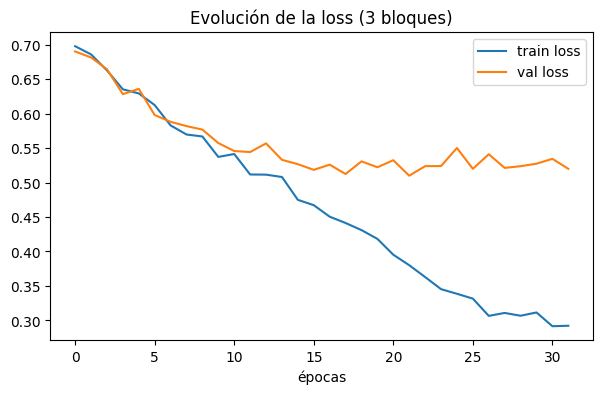

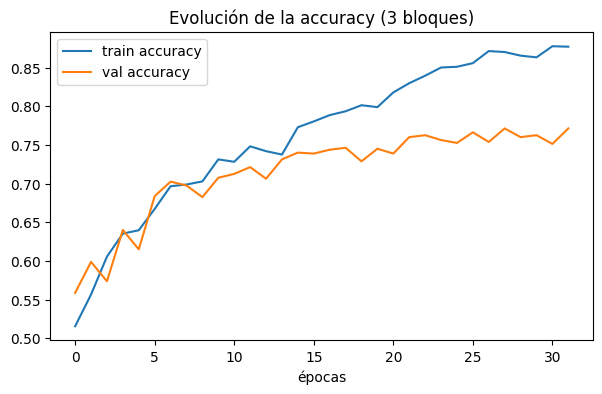

Mejor val_accuracy: 0.7713 (época 28)
Mejor val_loss: 0.5099 (época 22)


In [41]:
# ============================================================
# Curvas de entrenamiento
# ============================================================
history_3b_df = pd.DataFrame(history_3b.history)

plt.figure(figsize=(7, 4))
plt.plot(history_3b_df["loss"], label="train loss")
plt.plot(history_3b_df["val_loss"], label="val loss")
plt.title("Evolución de la loss (3 bloques)")
plt.xlabel("épocas"); plt.legend(); plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history_3b_df["accuracy"], label="train accuracy")
plt.plot(history_3b_df["val_accuracy"], label="val accuracy")
plt.title("Evolución de la accuracy (3 bloques)")
plt.xlabel("épocas"); plt.legend(); plt.show()

print(f"Mejor val_accuracy: {history_3b_df['val_accuracy'].max():.4f} "
      f"(época {history_3b_df['val_accuracy'].idxmax() + 1})")
print(f"Mejor val_loss: {history_3b_df['val_loss'].min():.4f} "
      f"(época {history_3b_df['val_loss'].idxmin() + 1})")

### Conclusión: comparativa 2 bloques vs 3 bloques

- **La arquitectura de 3 bloques mejora los resultados**: val_accuracy sube de 74.25% a **77.13%**, y val_loss mejora de 0.5283 a **0.5099**. Confirma la hipótesis de que la topología (no la resolución de imagen) era parte del cuello de botella.
- **El patrón de overfitting se mantiene**: en ambos modelos, train y val divergen a partir de la época ~10-15, con val_loss estancándose en una meseta ruidosa. Lo que cambia es el *nivel* de esa meseta (más alto en 3 bloques), no el comportamiento cualitativo.
- **La mejora es real pero moderada** (~3 puntos): sugiere que el techo actual ya no depende tanto de la arquitectura como de otros factores — previsiblemente la cantidad de datos (4000 imágenes) y el ruido visual del dataset (oclusiones, encuadres variados).

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7670 - loss: 0.4924

Test loss (3 bloques): 0.4924
Test accuracy (3 bloques): 0.7670
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

=== Classification report (3 bloques) ===
              precision    recall  f1-score   support

         cat       0.78      0.74      0.76       500
         dog       0.75      0.80      0.77       500

    accuracy                           0.77      1000
   macro avg       0.77      0.77      0.77      1000
weighted avg       0.77      0.77      0.77      1000



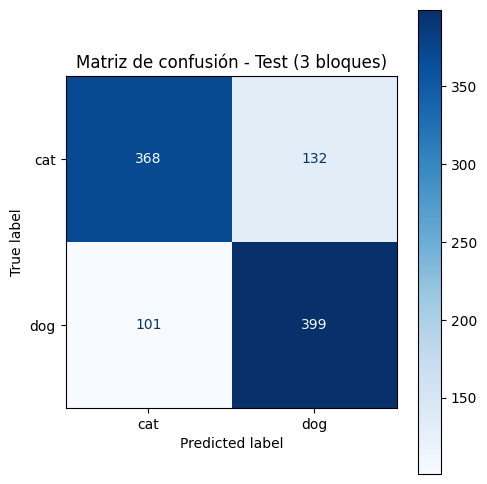


=== Comparativa ===
Test accuracy 2 bloques: 0.7620
Test accuracy 3 bloques: 0.7670


In [43]:
# ============================================================
# Evaluación en test
# ============================================================
test_loss_3b, test_accuracy_3b = model_3b.evaluate(X_test_norm, y_test_enc)
print(f"\nTest loss (3 bloques): {test_loss_3b:.4f}")
print(f"Test accuracy (3 bloques): {test_accuracy_3b:.4f}")

y_pred_probs_3b = model_3b.predict(X_test_norm).ravel()
y_pred_3b = (y_pred_probs_3b >= 0.5).astype(int)

print("\n=== Classification report (3 bloques) ===")
print(classification_report(y_test_enc, y_pred_3b, target_names=le.classes_))

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_enc, y_pred_3b,
    display_labels=le.classes_,
    ax=ax, cmap="Blues"
)
plt.title("Matriz de confusión - Test (3 bloques)")
plt.tight_layout()
plt.show()

# ============================================================
# Comparativa directa con el modelo de 2 bloques
# ============================================================
print("\n=== Comparativa ===")
print(f"Test accuracy 2 bloques: {test_accuracy:.4f}")
print(f"Test accuracy 3 bloques: {test_accuracy_3b:.4f}")

### Conclusión: comparación en test (2 bloques vs 3 bloques)

- **Mejora marginal en accuracy**: 76.20% (2 bloques) → 76.70% (3 bloques), solo +0.5 puntos — mucho menor que los ~3 puntos de mejora que sugería la validación.
- **La loss sí mejora más claramente**: de ~0.56 a 0.49, indicando predicciones algo mejor calibradas aunque no se traduzcan en muchos más aciertos.
- **El modelo de 3 bloques pierde la simetría entre clases**: en 2 bloques, precision/recall/f1 eran idénticos (0.76) en cat y dog. En 3 bloques aparece un sesgo hacia predecir "dog" (mejor recall en dog, 0.80, a costa de peor recall en cat, 0.74).
- **La ganancia de validación no se traslada 1:1 a test**: con 1000 imágenes de test, parte de la diferencia observada en validación puede deberse a variabilidad estadística más que a una mejora estructural sólida.

**Conclusión general**: 3 bloques ofrece una mejora real pero pequeña, a cambio de introducir un ligero sesgo hacia una clase. El margen de mejora restante probablemente dependa más de atacar el ruido/variabilidad del dataset (Data Augmentation) que de seguir profundizando la arquitectura.

### Argumentos para quedarse con el modelo de 2 bloques

- **Mejora marginal y poco fiable**: +0.5 puntos en test (76.20% → 76.70%) con solo 1000 imágenes está dentro del margen de ruido estadístico — no es una diferencia sobre la que apostar con confianza.
- **Pierde simetría entre clases**: 3 bloques introduce un sesgo hacia predecir "dog" que no existía en el modelo de 2 bloques, menos deseable para un problema balanceado como este.
- **Mayor coste computacional sin beneficio claro**: más parámetros y tiempo de entrenamiento, sin reducir de forma relevante el overfitting relativo (la brecha train/val es similar en ambos modelos).
- **Principio de simplicidad**: ante rendimiento prácticamente equivalente, el modelo más simple es preferible — más fácil de explicar, mantener y menos propenso a comportamientos inesperados.

**Conclusión**: la mejora real vendría de atacar el ruido/variabilidad del dataset (Data Augmentation), no de añadir más profundidad a la red — por eso se mantiene el modelo de 2 bloques como base.